In [1]:
%load_ext autoreload
%autoreload 2

In [60]:
import torch
import tiktoken
import matplotlib.pyplot as plt

import sys
sys.path.append('../scr')
from dataLoader import GPTDataset, create_dataloader
from attentionLayers import MultiHeadMaskedAttention
from gptmodel import LayerNorm, TransformerBlock, GPTModel
from training import train_model, generate_text_simple
torch.manual_seed(42)

In [3]:
print(torch.__version__)

2.5.1


In [4]:
torch.cuda.is_available()

True

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Check tokenizer

In [6]:
tokenizer = tiktoken.get_encoding("gpt2")

In [7]:
text = "Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownplace."
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 617, 34680, 5372, 13]


In [8]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownplace.


In [9]:
with open("../training_data/the-verdict.txt", "r") as f:
    raw_text = f.read()

In [10]:
dataset = GPTDataset(txt = raw_text, tokenizer=tokenizer, max_length=10, stride=10)

In [11]:
data_iter = iter(dataset)
first_batch = next(data_iter)

In [12]:
first_batch

(tensor([   40,   367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138]),
 tensor([  367,  2885,  1464,  1807,  3619,   402,   271, 10899,  2138,   257]))

# Check DataLoader

In [16]:
dataloader = create_dataloader(raw_text, batch_size=2, max_length = 10, stride = 10, shuffle=True, drop_last=True) # drop_last = True drops the last batch if it is shorter than the specified batch_size

In [17]:
dataloader_iter = iter(dataloader)

In [18]:
next(dataloader_iter)

[tensor([[  618,   314,  3521,   470,   804,   379,   326,  1517,   438, 24089],
         [  284,   884, 14177,  8233,  1020,  5768,    26,   290,  1719,    11]]),
 tensor([[  314,  3521,   470,   804,   379,   326,  1517,   438, 24089,    77],
         [  884, 14177,  8233,  1020,  5768,    26,   290,  1719,    11,   319]])]

# Check Multihead masked attention layer

In [19]:
d_in = 5
d_out = 4
context_length = 10
dropout = 0.2
num_heads = 2
qkv_bias = False
masked_attention = MultiHeadMaskedAttention(d_in = d_in, d_out = d_out, \
                                            context_length = context_length, \
                                            dropout = dropout, num_heads = num_heads, \
                                            qkv_bias = qkv_bias)

In [20]:
x = torch.rand(10, 5)

In [21]:
batch = torch.stack((x, x), dim = 0)

In [22]:
batch.shape

torch.Size([2, 10, 5])

In [23]:
outputs = masked_attention.forward(batch)

In [24]:
print(outputs.shape)

torch.Size([2, 10, 4])


# Check layer norm

In [26]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch)
mean = out_ln.mean(dim = -1, keepdim=True)
var = out_ln.var(dim = -1, keepdim=True)
print(mean)
print(var)

tensor([[[-3.5763e-08],
         [ 7.1526e-08],
         [ 9.5367e-08],
         [ 4.7684e-08],
         [-3.5763e-08],
         [-2.3842e-08],
         [-1.7881e-07],
         [ 2.3842e-08],
         [ 1.1921e-08],
         [ 0.0000e+00]],

        [[-3.5763e-08],
         [ 7.1526e-08],
         [ 9.5367e-08],
         [ 4.7684e-08],
         [-3.5763e-08],
         [-2.3842e-08],
         [-1.7881e-07],
         [ 2.3842e-08],
         [ 1.1921e-08],
         [ 0.0000e+00]]], grad_fn=<MeanBackward1>)
tensor([[[0.9998],
         [0.9999],
         [0.9998],
         [0.9997],
         [0.9999],
         [0.9998],
         [0.9994],
         [0.9986],
         [0.9999],
         [0.9999]],

        [[0.9998],
         [0.9999],
         [0.9998],
         [0.9997],
         [0.9999],
         [0.9998],
         [0.9994],
         [0.9986],
         [0.9999],
         [0.9999]]], grad_fn=<VarBackward0>)


In [27]:
out_ln = ln(batch)

In [28]:
out_ln

tensor([[[-1.2960,  0.5280,  0.3174, -0.7334,  1.1841],
         [ 0.9117, -0.9719, -0.7155,  1.2279, -0.4521],
         [ 0.0019, -1.3373, -0.4746,  1.3220,  0.4880],
         [-0.4948,  1.6995, -0.3695, -0.8536,  0.0183],
         [-1.1498, -0.8354,  1.3219,  0.2530,  0.4103],
         [-0.8963, -0.2834,  0.4360,  1.5227, -0.7791],
         [-0.5421, -1.2049,  1.1708, -0.3099,  0.8861],
         [-0.3648, -0.4165,  0.1912,  1.6136, -1.0235],
         [ 0.8885, -0.5390,  0.9187,  0.1632, -1.4315],
         [ 1.5933,  0.1259, -0.0382, -0.7160, -0.9650]],

        [[-1.2960,  0.5280,  0.3174, -0.7334,  1.1841],
         [ 0.9117, -0.9719, -0.7155,  1.2279, -0.4521],
         [ 0.0019, -1.3373, -0.4746,  1.3220,  0.4880],
         [-0.4948,  1.6995, -0.3695, -0.8536,  0.0183],
         [-1.1498, -0.8354,  1.3219,  0.2530,  0.4103],
         [-0.8963, -0.2834,  0.4360,  1.5227, -0.7791],
         [-0.5421, -1.2049,  1.1708, -0.3099,  0.8861],
         [-0.3648, -0.4165,  0.1912,  1.6136, 

# check TransformerBlock

In [29]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [30]:
x = torch.rand(2, 4, 768)

In [31]:
block = TransformerBlock(GPT_CONFIG_124M)

In [32]:
output = block(x)

In [33]:
x.shape

torch.Size([2, 4, 768])

In [34]:
output.shape

torch.Size([2, 4, 768])

# Check GPTMODEL

In [35]:
model = GPTModel(GPT_CONFIG_124M)

In [36]:
batch = torch.tensor([[6109, 3626, 6100, 345], [6109, 1110, 6622, 2576]])

In [37]:
batch.shape

torch.Size([2, 4])

In [38]:
output = model(batch)

In [39]:
output.shape

torch.Size([2, 4, 50257])

# Check the number of parameters

In [40]:
total_params = sum([p.numel() for p in model.parameters()]) # check number of elements

In [41]:
total_params

162419712

In [42]:
num_atten_params = sum([p.numel() for block in model.trf_blocks for p in block.att.parameters()])

In [43]:
num_ffn_params = sum([p.numel() for block in model.trf_blocks for p in block.ff.parameters()])

In [44]:
print(num_atten_params)
print(num_ffn_params)

28320768
56669184


# Generate text

In [45]:
start_context = 'Hello, I am'
encoded = tokenizer.encode(start_context)
print(encoded)

[15496, 11, 314, 716]


In [46]:
encoded_tensor = torch.tensor(encoded).unsqueeze(0)

In [47]:
generated_encoded = generate_text_simple(model=model,
                     idx = encoded_tensor,
                     max_new_tokens = 10,
                     context_size = 5)

In [48]:
tokenizer.decode(generated_encoded.squeeze().tolist())

'Hello, I am Heavy FijiEMA todaySB accommodations reasons openings terrorism db'

# Training

In [49]:
file_path = '../training_data/the-verdict.txt'
with open(file_path, 'r') as f:
    text_data = f.read()

In [50]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

In [51]:
total_characters

20479

In [52]:
total_tokens

5145

In [53]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [54]:
torch.manual_seed(123)
train_loader = create_dataloader(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [55]:
len(train_loader)

9

In [56]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [57]:
print("Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [58]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epochs = 50
train_loss, val_losses, toekn_seen = train_model(
    model, train_loader, val_loader, optimizer,
    device, num_epochs = num_epochs, eval_freq=5, eval_iter=1,
    start_context = "Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000) Train loss 10.061, Val loss 9.926
Ep 1 (Step 000005) Train loss 8.156, Val loss 8.340
Every effort moves you,,,,,,,,,,,,.





































Ep 2 (Step 000010) Train loss 6.559, Val loss 7.052
Ep 2 (Step 000015) Train loss 5.924, Val loss 6.602
Every effort moves you, and,, and,, and,,,, and,.



































Ep 3 (Step 000020) Train loss 5.831, Val loss 6.487
Ep 3 (Step 000025) Train loss 5.420, Val loss 6.400
Every effort moves you, and, and, and, and, and, and, and. G. Gis, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030) Train loss 4.735, Val loss 6.329
Ep 4 (Step 000035) Train loss 5.114, Val loss 6.336
Every effort moves you, and a. Gisburn, and a, and a.













"I"--as Jack a of the of the of the of the picture"I had been the of
Ep 5 (Step 000040) Train loss 4.394, Val loss 6.254
Every effort moves you, I felt, and I felt--as he had been the picture of the honour of the pic

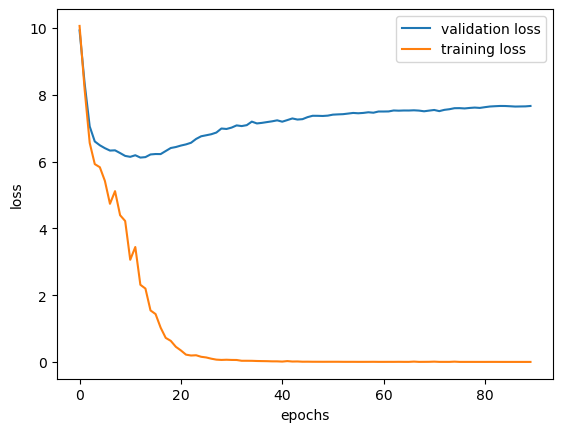

In [63]:
plt.plot(val_losses, label = 'validation loss')
plt.plot(train_loss, label = 'training loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

# Generate samples from trained model

In [ ]:
model.eval() # turn off droupout 

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadMaskedAttention(
        (W_Q): Linear(in_features=768, out_features=768, bias=False)
        (W_K): Linear(in_features=768, out_features=768, bias=False)
        (W_V): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (output_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadMaskedAttention(
        (W_Q): Linear(in_feature

In [86]:
def generate(model, starting_context, max_length, context_size,
             temperatue = 1.0, top_k = None, eos_id = None):
    
    # encode the starting_context
    idx = tokenizer.encode(starting_context)
    idx = torch.tensor(idx).unsqueeze(0).to(device)

    # generate new tokens using the model
    for i in range(max_length):
        idx_input = idx[:,-context_size:]
        with torch.no_grad():
            logits = model(idx_input)
        # take the logits for the last word
        logits = logits[:, -1, :]

        if top_k != None:
            # keep only top k tokens
            top_logits, _ = torch.topk(logits, top_k, dim=-1) 
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        # apply temperatue rescaling
        logits = logits / temperatue
        probs = torch.softmax(logits, dim = -1)
        idx_next = torch.multinomial(probs, num_samples=1)
        if idx_next == eos_id:
            break
    
        idx = torch.cat((idx, idx_next), dim = 1)

    return tokenizer.decode(idx.squeeze().tolist())

In [90]:
starting_context = 'Hi, how are you today?'

In [93]:
generate(model, starting_context, max_length = 100, context_size = 256, temperatue = 4, top_k = 25, eos_id = None)

'Hi, how are you today? You surprise pushed one of my way laid down handsome, bas--she had the yourself comfortable his glory"Neverurance. Th, display of his glory him better through I had again"? may heard a rich "strong work!" stopping found her az! She glanced at the sure it suddenly last for surrounded except one of art and check The younger had dropped veins, a balancing his history all patient my painting a tried faith, why I was just threw back to when I efforts whatstalk up his pictures'

# save models

In [94]:
torch.save(model.state_dict, "../models/modelv1.pth")